# Интеллектуальный анализ данных – весна 2026
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [1]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [2]:
df = pd.read_csv('tweets_coronavirus.csv', encoding='latin-1')
df.head(10)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,Positive
5,3805,48757,"35.926541,-78.753267",16-03-2020,Cashier at grocery store was sharing his insig...,Positive
6,3807,48759,"Atlanta, GA USA",16-03-2020,Due to COVID-19 our retail store and classroom...,Positive
7,3808,48760,"BHAVNAGAR,GUJRAT",16-03-2020,"For corona prevention,we should stop to buy th...",Negative
8,3810,48762,"Pitt Meadows, BC, Canada",16-03-2020,"Due to the Covid-19 situation, we have increas...",Extremely Positive
9,3811,48763,Horningsea,16-03-2020,#horningsea is a caring community. LetÃÂs AL...,Extremely Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [3]:
df["Sentiment"] = ((df["Sentiment"] == "Extremely Positive") | (df["Sentiment"] == "Positive")).astype(int)
df.head(10)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,1
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,1
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,1
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",0
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,1
5,3805,48757,"35.926541,-78.753267",16-03-2020,Cashier at grocery store was sharing his insig...,1
6,3807,48759,"Atlanta, GA USA",16-03-2020,Due to COVID-19 our retail store and classroom...,1
7,3808,48760,"BHAVNAGAR,GUJRAT",16-03-2020,"For corona prevention,we should stop to buy th...",0
8,3810,48762,"Pitt Meadows, BC, Canada",16-03-2020,"Due to the Covid-19 situation, we have increas...",1
9,3811,48763,Horningsea,16-03-2020,#horningsea is a caring community. LetÃÂs AL...,1


Сбалансированы ли классы?

In [4]:
df['Sentiment'].value_counts()

Sentiment
1    18046
0    15398
Name: count, dtype: int64

**Ответ:** В данных есть не большой перекос в сторону положительных твиттов, но он не значителен. Можно считать, что классы сбалансированы.

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [5]:
df.isna().sum(axis=0)

UserName            0
ScreenName          0
Location         7049
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

In [6]:
df.fillna("Unknown")

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,1
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,1
2,3802,48754,Unknown,16-03-2020,My food stock is not the only one which is emp...,1
3,3803,48755,Unknown,16-03-2020,"Me, ready to go at supermarket during the #COV...",0
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,1
...,...,...,...,...,...,...
33439,44949,89901,OHIO,14-04-2020,I never that weÃÂd be in a situation &amp; w...,1
33440,44950,89902,Unknown,14-04-2020,@MrSilverScott you are definitely my man. I fe...,1
33441,44952,89904,Unknown,14-04-2020,Response to complaint not provided citing COVI...,0
33442,44953,89905,Unknown,14-04-2020,You know itÃÂs getting tough when @KameronWi...,1


Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [7]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, train_size=0.7, random_state=0) 

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [8]:
from collections import Counter

counter = Counter()
train["OriginalTweet"].apply(lambda x: counter.update(x.lower().split()))

25621    None
30135    None
28899    None
5989     None
4367     None
         ... 
20757    None
32103    None
30403    None
21243    None
2732     None
Name: OriginalTweet, Length: 23410, dtype: object

Какой размер словаря получился?

In [9]:
print(f"Всего токенов: {sum(counter.values())}")
print(f"Уникальных токенов: {len(counter)}")

Всего токенов: 754630
Уникальных токенов: 79755


Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [10]:
for token, count in counter.most_common(10):
    print(f"{token}:{count}")

the:26815
to:23373
and:14684
of:13012
a:11737
in:11198
for:8566
#coronavirus:8223
is:7383
are:7050


**Ответ:** Наиболее часто встречающимися словами являются артикли, союзы, предлоги и формы глагола be. Сами по себе они не несут смысловой нагрузки и могут использоваться в текстах любой окраски. Также, сами по себе, это часто встречающиеся слова.  
Выбивается лишь "#coronavirus". По всей видимости, твиты собирались в начале 20-ых годов.

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [11]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

for sw in stopwords.words("english"):
    counter.pop(sw, None)


for token, count in counter.most_common(10):
    print(f"{token}:{count}")

#coronavirus:8223
prices:3891
food:3820
grocery:3469
supermarket:3288
people:3175
covid-19:3173
store:3155
#covid19:2471
&amp;:2314


**Ответ:**  Теперь в топе нет предлогов, союзов и других мало-информативных слов.

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [12]:
for token, count in counter.most_common()[-20:]:
    print(f"{token}:{count}")

skellig:1
coast!:1
closer!):1
@skelligsix18:1
#skelligcoast2kms:1
#southkerry:1
https://t.co/zjcl195vqs:1
@srinivasiyc:1
https://t.co/iaek4fwsgz:1
premiership:1
non-playing:1
subsidise:1
playersãâ:1
renewing:1
wage!:1
flew:1
nothing...:1
@torontopearson:1
@680news:1
https://t.co/7j2y3rsld9:1


**Ответ:** Часть самых редких токенов - это смесь слова и знаков припинания. Их нужно разделять, т.к. в оставлении их в таком виде нет смысла, они лишь расширяют словарь.   
Остальное - это теги человека, хештеги и ссылки. Изменять их нет смысла, т.к. они неделимы. Но и оставлять их вероятно не стоит, т.к. они встречаются слишком редко, чтоб модель смогла на них чему-то научиться. 



Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [13]:
from nltk.tokenize import TweetTokenizer

tw = TweetTokenizer()
tw_counter = Counter()
train["OriginalTweet"].apply(lambda x: tw_counter.update(tw.tokenize(x)))

for token, count in tw_counter.most_common(10):
    print(f"{token}:{count}")

the:24337
.:24118
to:22933
,:17571
and:14354
of:12904
a:11045
in:10573
?:9524
for:8228


**Ответ:** Токеназер выделил в отдельные токены знаки припинания.

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [14]:
from string import punctuation

for sw in stopwords.words("english") + list(punctuation):
    tw_counter.pop(sw, None)

for token, count in tw_counter.most_common(10):
    print(f"{token}:{count}")

Â:7415
:7311
19:7167
#coronavirus:7143
I:5235
:4372
prices:4281
COVID:4218
food:3795
store:3691


**Ответ:** Остались токены с неправильной кодировкой. Скорее всего это эмоджи.

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [15]:
tw_counter = Counter({token: count for token, count in tw_counter.items() if len(token) > 1 or ord(token) < 128})

print("Наиболее частые токены:")
for token, count in tw_counter.most_common(10):
    print(f"{token}: {count}")


Наиболее частые токены:
19: 7167
#coronavirus: 7143
I: 5235
prices: 4281
COVID: 4218
food: 3795
store: 3691
supermarket: 3373
grocery: 3083
people: 3047


In [16]:
print("Наименее частые токены:")
for token, count in tw_counter.most_common()[-20:]:
    print(f"{token}: {count}")

Наименее частые токены:
ruins: 1
now.When: 1
milion: 1
Skellig: 1
@SkelligSix18: 1
#SkelligCoast2kms: 1
#SouthKerry: 1
https://t.co/zJcL195VQS: 1
@srinivasiyc: 1
https://t.co/IAEK4fWsgz: 1
Vile: 1
premiership: 1
non-playing: 1
subsidise: 1
playersÃ: 1
renewing: 1
flew: 1
@TorontoPearson: 1
@680NEWS: 1
https://t.co/7j2Y3rSld9: 1


**Ответ:** Нет лишних знаков припинания и символов в неправильной кодировке. 

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [17]:
i = 0

for token, count in tw_counter.most_common():
    if token[0] == "#":
        print(f"{token}: {count}")
        i += 1
        if (i == 10): break

#coronavirus: 7143
#COVID19: 1844
#Covid_19: 1463
#Coronavirus: 1281
#COVID2019: 927
#toiletpaper: 657
#covid19: 568
#COVID: 542
#CoronaCrisis: 426
#CoronaVirus: 351


**Ответ:** В выборке очень много хэштегов о ковиде.

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [18]:
for token, count in tw_counter.most_common():
    if "https://t.co" in token:
        print(f"{token}: {count}")
        i += 1
        if (i == 10): break

https://t.co/oXA7SWtoNd: 5
https://t.co/gP3EusapL8: 4
https://t.co/DefTruI1PfÃÂ: 3
https://t.co/WrLHYzIzAA: 3
https://t.co/kuwIpF1KQW: 3
https://t.co/zjNRx6dKKN: 3
https://t.co/3GBBDpdjat: 3
https://t.co/e2ZNXajPre: 3
https://t.co/CATKegAyOY: 3
https://t.co/G63RP042HO: 3
https://t.co/AZIqCdgrNn: 3
https://t.co/bYlqXrjmNT: 3
https://t.co/WuiEEfSNOj: 3
https://t.co/OI39zSAnQ8: 3
https://t.co/rAfJ2l2cEQ: 2
https://t.co/oF8ENb5KXP: 2
https://t.co/ozenIAsfEO: 2
https://t.co/9Gjx7znzF4: 2
https://t.co/i7Lk8xuvMr: 2
https://t.co/sKWgk66i8z: 2
https://t.co/R7sAGojsjg: 2
https://t.co/VjpA809ZOL: 2
https://t.co/f5CioNSHdV: 2
https://t.co/2rbbMlM48a: 2
https://t.co/ilqrMMQKTB: 2
https://t.co/zz2eou6gQz: 2
https://t.co/7TxoJQDL04: 2
https://t.co/XAauDKWfkF: 2
https://t.co/mhbd0oKG5h: 2
https://t.co/U5SPsDh0bf: 2
https://t.co/pj4RIcPwYa: 2
https://t.co/8DShYHJJnY: 2
https://t.co/Hpo7UWkakl: 2
https://t.co/uPEcwUXjz5: 2
https://t.co/eOLXnwkXTS: 2
https://t.co/hSHap8C7tP: 2
https://t.co/iDrwMv5XvD: 

**Ответ:** Вряд ли ссылки будут полезны, т.к. их мало, и модель вряд ли сможет увидеть в них какую-нибудь закономерность.

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [19]:
def custom_tokenizer(text):
  text.lower()

  tw = TweetTokenizer()
  tokens = tw.tokenize(text)

  tokens = [token for token in tokens if (token not in stopwords.words("english") + list(punctuation)) and (len(token) > 1 or ord(token) < 128) and ("https://t.co" not in token)]
  
  return tokens


In [20]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['This', 'sample', 'text', '@Sample_text', 'I', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer() 
cv.fit(train["OriginalTweet"])

print(len(cv.vocabulary_))

52798


**Ответ:** Количество уникальных токенов на ~20к меньше. По всей видимости, были удалены стоп-слова и редкие токены.

Посмотрим на какой-нибудь конкретный твитт:

In [22]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 np.int64(0))

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [23]:
print(cv.transform([train.iloc[ind]['OriginalTweet']]))

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 18 stored elements and shape (1, 52798)>
  Coords	Values
  (0, 8250)	1
  (0, 8846)	1
  (0, 11977)	1
  (0, 12343)	1
  (0, 18167)	1
  (0, 18811)	1
  (0, 18922)	1
  (0, 19163)	1
  (0, 23770)	1
  (0, 27650)	1
  (0, 32221)	1
  (0, 32629)	1
  (0, 33677)	1
  (0, 34624)	1
  (0, 36296)	1
  (0, 37804)	1
  (0, 42025)	1
  (0, 42427)	1


**Ответ:** На основе полученного вектора невозможно выделить более и менне важные токены, т.к. этот токенайзер лишь подсчитывает количество токенов в тексте.

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tv = TfidfVectorizer()

tv.fit(train["OriginalTweet"])

print(tv.transform([train.iloc[ind]['OriginalTweet']]))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 18 stored elements and shape (1, 52798)>
  Coords	Values
  (0, 8250)	0.37980260115138875
  (0, 8846)	0.1333423763630868
  (0, 11977)	0.22177762147152172
  (0, 12343)	0.1652234982924507
  (0, 18167)	0.31662019798552826
  (0, 18811)	0.1097872602550264
  (0, 18922)	0.08605723400414655
  (0, 19163)	0.30341116125035644
  (0, 23770)	0.07720780744802226
  (0, 27650)	0.29578909426242755
  (0, 32221)	0.24934088837073284
  (0, 32629)	0.12715158197633206
  (0, 33677)	0.1591245400461617
  (0, 34624)	0.14242149357720232
  (0, 36296)	0.2504165018008069
  (0, 37804)	0.34796756143689067
  (0, 42025)	0.23939641380986615
  (0, 42427)	0.30203356606708864


**Ответ:** Теперь важность токена определить проще. TfidfVectorizer использует TF-IDF для вычесления весов. Чем больше вес, тем важнее токен.

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [25]:
tweet = train[train['OriginalTweet'].apply(lambda x: ('great' in x) and (len(x) <= 200)) & (train['Sentiment'] == 1)].iloc[12]["OriginalTweet"]
tweet

'With people hoarding food to self isolate I m thinking this might be a great time to invest in Weight Watchers stock'

In [26]:
vector = tv.transform([tweet])

indices = vector.indices
values = vector.data

tokens = tv.get_feature_names_out()

for idx, val in zip(indices, values):
    print(f"{tokens[idx]}: {val:.4f}")

be: 0.1313
food: 0.1229
great: 0.2205
hoarding: 0.2356
in: 0.0865
invest: 0.3367
isolate: 0.2936
might: 0.2512
people: 0.1332
self: 0.2341
stock: 0.1772
thinking: 0.2788
this: 0.1182
time: 0.1681
to: 0.1307
watchers: 0.4558
weight: 0.3592
with: 0.1250


**Ответ:** Наиболее значимыми получились "watchers" и "weight". Связано это с тем, как расчитывается TF-IDF. TF-IDF = (количество вхождений токена в документ / всего токенов) * log(общее количество документов / количество документов содержащих этот токен). По всей видимости, в выборке мало документов содержащих эти токены.

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [27]:
cv = CountVectorizer()
tv = TfidfVectorizer()

X_train_cv = cv.fit_transform(train["OriginalTweet"])
X_train_tv = tv.fit_transform(train["OriginalTweet"])

X_test_cv = cv.transform(test["OriginalTweet"])
X_test_tv = tv.transform(test["OriginalTweet"])

y_train = train["Sentiment"]
y_test = test["Sentiment"]


Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_cv = LogisticRegression(C=0.07) #Без C сильно переобучалась 
lr_tv = LogisticRegression()

lr_cv.fit(X_train_cv, y_train)
lr_tv.fit(X_train_tv, y_train)

print("\t train \t test")
print(f"CV \t {np.round(accuracy_score(y_train, lr_cv.predict(X_train_cv)), 2)} \t {np.round(accuracy_score(y_test, lr_cv.predict(X_test_cv)), 2)}")
print(f"TV \t {np.round(accuracy_score(y_train, lr_tv.predict(X_train_tv)), 2)} \t {np.round(accuracy_score(y_test, lr_tv.predict(X_test_tv)), 2)}")

	 train 	 test
CV 	 0.91 	 0.86
TV 	 0.92 	 0.85


**Ответ:** Модели показали примерно одинаковый результат. Это произошло из-за того, что TV лишь меняет веса, не добавляя и не убирая информацию. Модель может добиться тех же результатов и при помощи CV.

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [29]:
from nltk.stem.snowball import SnowballStemmer

ENGLISH_STOPWORDS = set(stopwords.words("english")) | set(punctuation)

def custom_stem_tokenizer(text):
    text = text.lower()
    tokens = tw.tokenize(text)
    stemmer = SnowballStemmer("english")
    tokens = [stemmer.stem(token) for token in tokens 
              if token not in ENGLISH_STOPWORDS
              and (len(token) > 1 or ord(token) < 128)
              and "https://t.co" not in token]
    return tokens

In [30]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [31]:


cv = CountVectorizer(tokenizer=custom_stem_tokenizer)
tv = TfidfVectorizer(tokenizer=custom_stem_tokenizer)

X_train_cv = cv.fit_transform(train["OriginalTweet"])
X_train_tv = tv.fit_transform(train["OriginalTweet"])

X_test_cv = cv.transform(test["OriginalTweet"])
X_test_tv = tv.transform(test["OriginalTweet"])

y_train = train["Sentiment"]
y_test = test["Sentiment"]


print(len(cv.vocabulary_))

d:\python\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36632


**Ответ** Словарь уменьшился практически в два раза, что неплохо оптимизирует модель. А в языках по типу русского, в которых у одного слова есть множесто форм, результат будет еще заметнее.

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [32]:
lr_cv = LogisticRegression(C=0.07) 
lr_tv = LogisticRegression()

lr_cv.fit(X_train_cv, y_train)
lr_tv.fit(X_train_tv, y_train)

print("\t train \t test")
print(f"CV \t {np.round(accuracy_score(y_train, lr_cv.predict(X_train_cv)), 2)} \t {np.round(accuracy_score(y_test, lr_cv.predict(X_test_cv)), 2)}")
print(f"TV \t {np.round(accuracy_score(y_train, lr_tv.predict(X_train_tv)), 2)} \t {np.round(accuracy_score(y_test, lr_tv.predict(X_test_tv)), 2)}")

	 train 	 test
CV 	 0.9 	 0.85
TV 	 0.92 	 0.86


**Ответ:** Результат остался примерно такой же, но модель теперь в два раза меньше. А в других языках можно добиться уменьшения модели во много раз. Поэтому использование стемминга имеет смысл.

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [33]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer, max_df=7000).fit(train["OriginalTweet"])

print(len(cv_df.vocabulary_))

d:\python\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36631


**Ответ:** У меня был словарь размером 36`632. На мой взягляд 7к не такое и большое число для такой выборки. Вероятно самый популярный токен - это хэштег о ковиде.

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [34]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer, min_df=11).fit(train["OriginalTweet"])
                        
print(len(cv_df.vocabulary_))

3687


In [35]:
lr_cv = LogisticRegression()
lr_cv.fit(cv_df.transform(train["OriginalTweet"]), y_train)

print("\t train \t test")
print(f"CV \t {np.round(accuracy_score(y_train, lr_cv.predict(cv_df.transform(train["OriginalTweet"]))), 2)} \t {np.round(accuracy_score(y_test, lr_cv.predict(cv_df.transform(test["OriginalTweet"]))), 2)}")

	 train 	 test
CV 	 0.93 	 0.87


**Ответ:** Значени опять же примерное, точно получить 3700 нельзя. Результат чуть улучшился, ушло переобучение, а модель удалось сократить в ~20 раз.

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

In [36]:
from sklearn.preprocessing import MaxAbsScaler #Интерпретатор ругался на StandardScaler, т.к. он бы сделал из разреженной матрицы обычную.

cv = CountVectorizer(tokenizer=custom_stem_tokenizer, min_df=11)

X_train_cv_m = cv.fit_transform(train["OriginalTweet"])
X_test_cv_m = cv.transform(test["OriginalTweet"])

ss = MaxAbsScaler ()

X_train_cv_ms = ss.fit_transform(X_train_cv_m)
X_test_cv_ms = ss.transform(X_test_cv_m)

lr_cv = LogisticRegression()

lr_cv.fit(X_train_cv_ms, y_train)

print("\t train \t test")
print(f"CV \t {np.round(accuracy_score(y_train, lr_cv.predict(X_train_cv_ms)), 2)} \t {np.round(accuracy_score(y_test, lr_cv.predict(X_test_cv_ms)), 2)}")

d:\python\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


	 train 	 test
CV 	 0.92 	 0.86


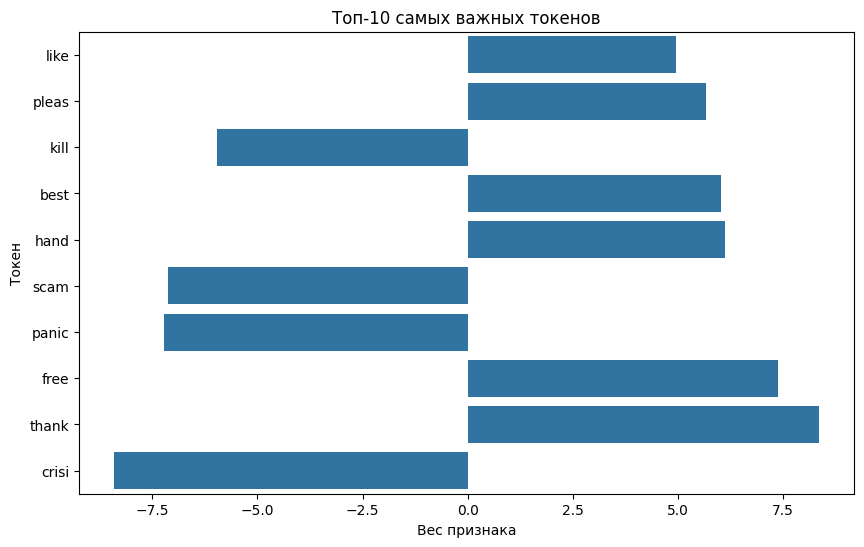

In [37]:
weights = lr_cv.coef_[0]
feature_names = cv.get_feature_names_out()

top_indices = np.argsort(np.abs(weights))[-10:]   

top_weights = weights[top_indices]
top_tokens = feature_names[top_indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_weights, y=top_tokens)
plt.xlabel('Вес признака')
plt.ylabel('Токен')
plt.title('Топ-10 самых важных токенов')
plt.show()

**Ответ:** Все слова имеют четкий тональный окрас. 

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [38]:
max_un = df.groupby("UserName")["Sentiment"].agg(["count"]).max()
max_sn = df.groupby("ScreenName")["Sentiment"].agg(["count"]).max()
print(f"max_un = {max_un}, max_sn = {max_sn}")

max_un = count    1
dtype: int64, max_sn = count    1
dtype: int64


**Ответ:** В выборке максимум по одному твиту на пользователя. Конкретно в этом случае добявление этих признаков не увеличит точность на тестовой выборке. 

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

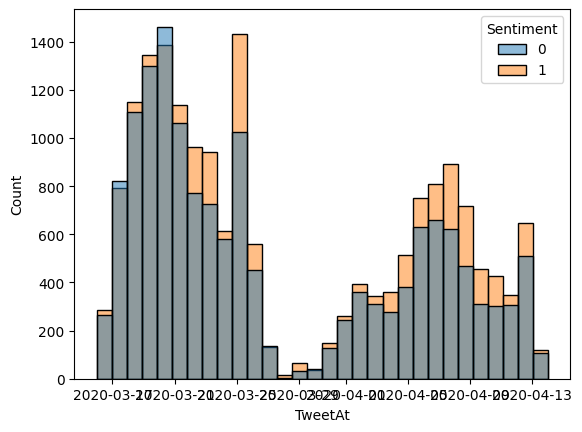

In [39]:
df["TweetAt"] = pd.to_datetime(df["TweetAt"], dayfirst=True)

sns.histplot(data=df, x="TweetAt", hue="Sentiment", bins=30)
plt.show()

**Ответ:** Дата может быть полезна.



In [40]:
from scipy.sparse import hstack

train_dates = pd.to_datetime(train["TweetAt"], dayfirst=True)

train_date_features = pd.DataFrame({
    'year': train_dates.dt.year,
    'month': train_dates.dt.month,
    'day': train_dates.dt.day,
    'dayofweek': train_dates.dt.dayofweek,
    'hour': train_dates.dt.hour,
    'minute': train_dates.dt.minute
}).to_numpy()

X_train_cv_ms = hstack([train_date_features, X_train_cv_ms])

test_dates = pd.to_datetime(test["TweetAt"], dayfirst=True)

test_date_features = pd.DataFrame({
    'year': test_dates.dt.year,
    'month': test_dates.dt.month,
    'day': test_dates.dt.day,
    'dayofweek': test_dates.dt.dayofweek,
    'hour': test_dates.dt.hour,
    'minute': test_dates.dt.minute
}).to_numpy()

X_test_cv_ms = hstack([test_date_features, X_test_cv_ms])

ss = MaxAbsScaler ()

X_train_cv_ms = ss.fit_transform(X_train_cv_m)
X_test_cv_ms = ss.transform(X_test_cv_m)

lr = LogisticRegression()

lr.fit(X_train_cv_ms, y_train)

print("\t train \t test")
print(f"CV \t {np.round(accuracy_score(y_train, lr.predict(X_train_cv_ms)), 2)} \t {np.round(accuracy_score(y_test, lr.predict(X_test_cv_ms)), 2)}")

	 train 	 test
CV 	 0.92 	 0.86


Ответ: Разници в точности нет.

Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [45]:
print(f"Уникальных значений location: {len(df["Location"].value_counts())}")

Уникальных значений location: 10465


Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

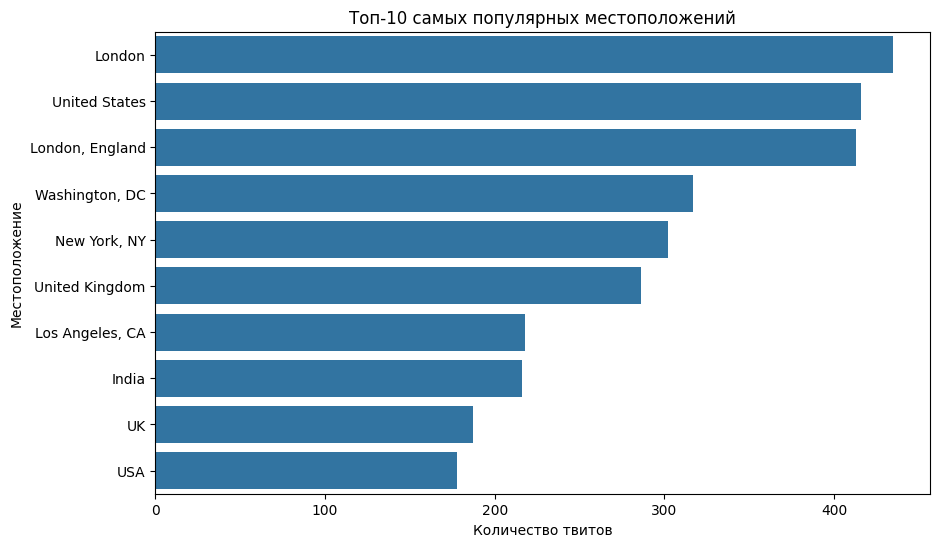

In [51]:
top_locations = df[df["Location"] != "Unknown"]["Location"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.xlabel('Количество твитов')
plt.ylabel('Местоположение')
plt.title('Топ-10 самых популярных местоположений')
plt.show()

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

Количество уникальных категорий: 6117


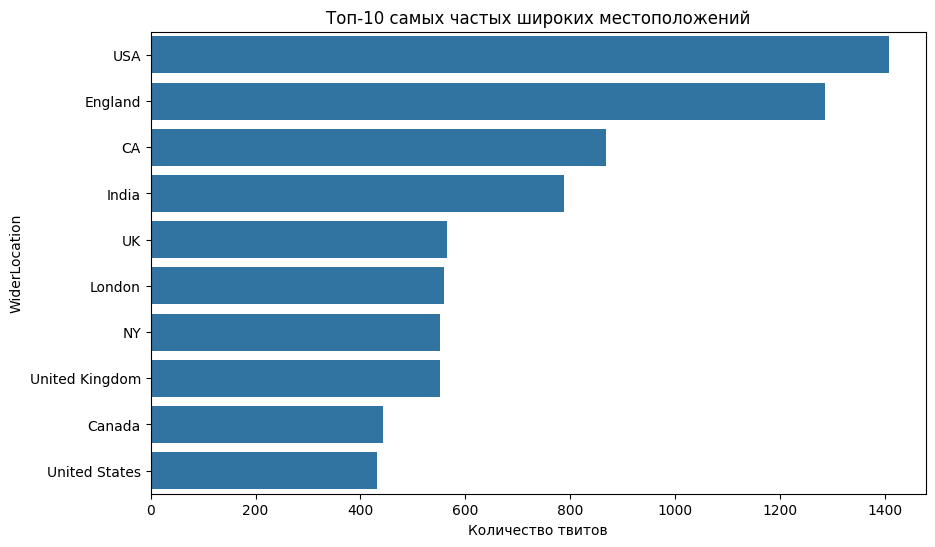

In [53]:
df['WiderLocation'] = df['Location'].apply(
    lambda x: x.split(',')[-1].strip() if pd.notna(x) and x != 'Unknown' else 'Unknown'
)

unique_wide = df[df['WiderLocation'] != 'Unknown']['WiderLocation'].nunique()
print(f"Количество уникальных категорий: {unique_wide}")

top_wide = df[df['WiderLocation'] != 'Unknown']['WiderLocation'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_wide.values, y=top_wide.index)
plt.xlabel('Количество твитов')
plt.ylabel('WiderLocation')
plt.title('Топ-10 самых частых широких местоположений')
plt.show()

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [55]:
from sklearn.preprocessing import OneHotEncoder

train['WiderLocation'] = train['Location'].apply(lambda x: x.split(',')[-1].strip() if pd.notna(x) and x != 'Unknown' else 'Unknown')
test['WiderLocation'] = test['Location'].apply(lambda x: x.split(',')[-1].strip() if pd.notna(x) and x != 'Unknown' else 'Unknown')

freq = train['WiderLocation'].value_counts()
keep = freq[freq > 1].index.tolist()
print(f"Оставляем {len(keep)} категорий")

ohe = OneHotEncoder(categories=[keep], sparse_output=True, handle_unknown='ignore')
X_train_wide = ohe.fit_transform(train[['WiderLocation']])
X_test_wide = ohe.transform(test[['WiderLocation']])

Оставляем 988 категорий


Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [56]:
X_train = hstack([X_train_cv_ms, X_train_wide])
X_test = hstack([X_test_cv_ms, X_test_wide])

lr = LogisticRegression()
lr.fit(X_train, y_train)

print("\t train \t test")
print(f"CV \t {np.round(accuracy_score(y_train, lr.predict(X_train)), 2)} \t {np.round(accuracy_score(y_test, lr.predict(X_test)), 2)}")

	 train 	 test
CV 	 0.92 	 0.86


**Ответ:** Признаки не повлияли на точность.